There are 13 cases in which LP has profits in two steps
There are 10 cases in which LP has profits in one step


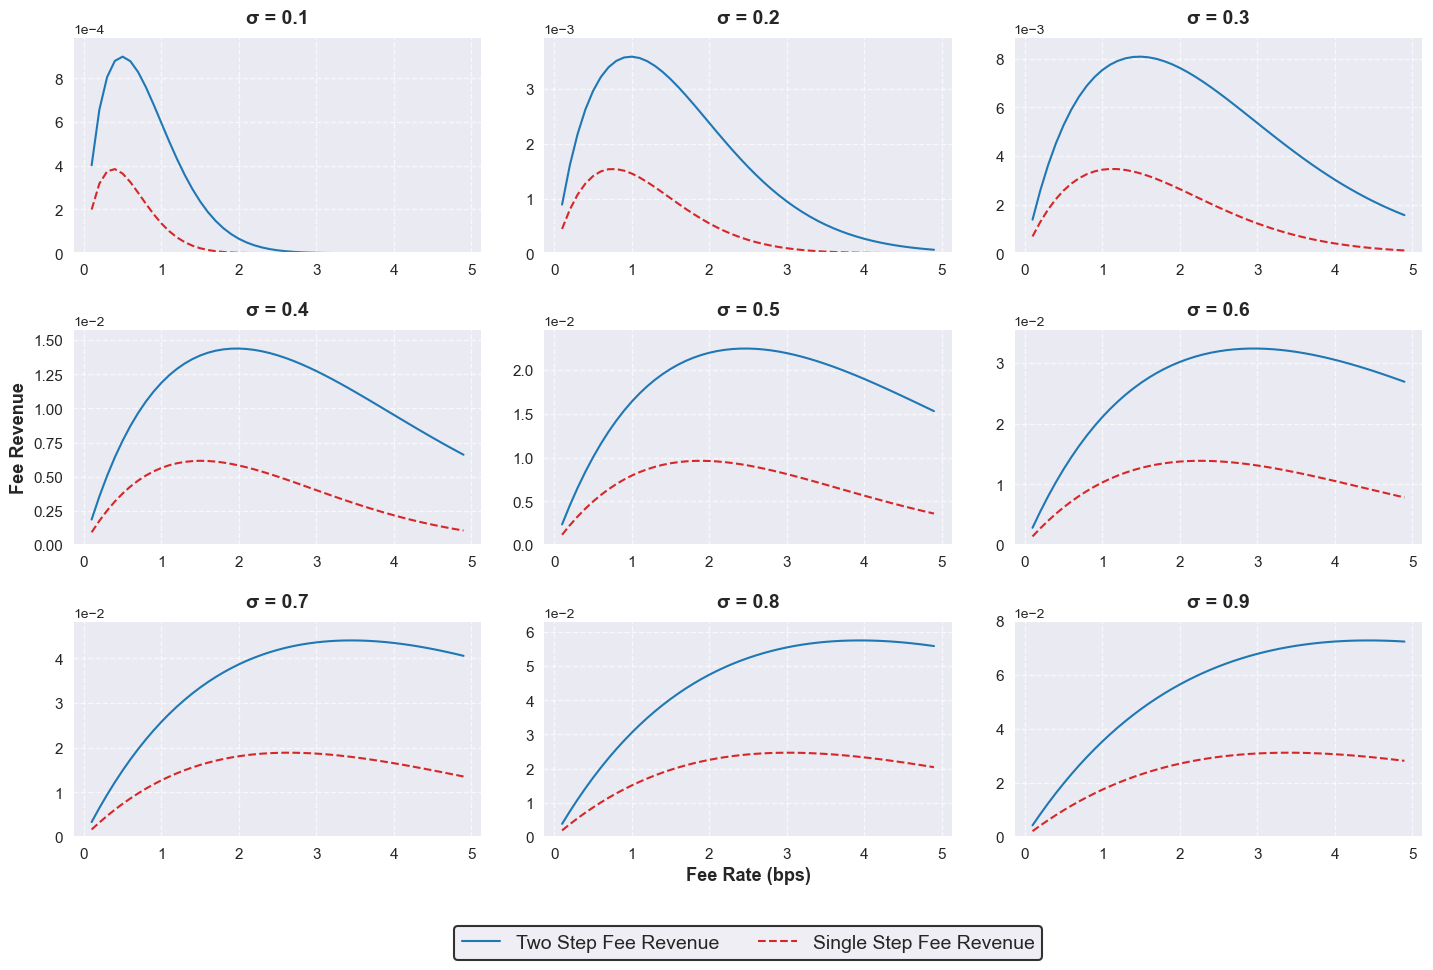

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_metrics(df, metric_names):
    # Get unique sigma values
    unique_sigmas = sorted(df['sigma'].unique())
    
    # Create a 3x3 grid of subplots with extra space for legend
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()  # Flatten for easier indexing
    
    # Use more professional colors and linestyles
    colors = ['#1f77b4', '#d62728']  # Blue and Red from matplotlib's default
    linestyles = ['-', '--']
    linewidth = 1.5  # Thicker lines for better visibility
    
    # Store legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Create plots for each sigma value
    for idx, sigma in enumerate(unique_sigmas):
        if idx >= 9:  # Safety check for more than 9 sigma values
            break
            
        # Filter data for current sigma
        sigma_data = df[df['sigma'] == sigma]
        
        # Create plot for each metric
        ax = axes[idx]
        for i, metric_name in enumerate(metric_names):
            # Convert gamma to basis points (multiply by 10000)
            line = ax.plot(sigma_data['gamma'] * 10000, sigma_data[metric_name], 
                         color=colors[i % len(colors)], 
                         linestyle=linestyles[i % len(linestyles)],
                         linewidth=linewidth)
            
            max_fee = sigma_data[metric_names].max().max()
            ax.set_ylim(0.0, max_fee * 1.1)
            
            # Collect legend info from first subplot only
            if idx == 0:
                legend_handles.extend(line)
                if metric_name == 'single_step_fee_revenue':
                    legend_labels.append('Single Step Fee Revenue')
                else:
                    legend_labels.append('Two Step Fee Revenue')
        
        # Customize plot
        ax.set_title(f'σ = {sigma:.1f}', fontsize=14, fontweight='bold', pad=10)
        
        
        # Scientific notation for y-axis
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        
        # Only add x-label to the bottom row (indices 6,7,8)
        if idx == 7:
            ax.set_xlabel('Fee Rate (bps)', fontsize=13, fontweight='bold')
        else:
            ax.set_xlabel('')
            
        # Only add y-label to the middle plot on the left side (index 3)
        if idx == 3:
            ax.set_ylabel('Fee Revenue', fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Customize grid and spines
        ax.grid(True, linestyle='--', alpha=0.7)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        # Increase tick label size
        ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Hide any unused subplots
    for idx in range(len(unique_sigmas), 9):
        axes[idx].set_visible(False)

    # Place legend at the bottom with enhanced styling
    legend = fig.legend(legend_handles, legend_labels, 
                       loc='upper center', bbox_to_anchor=(0.53, 0.05),
                       fontsize=14, ncol=2,
                       frameon=True, edgecolor='black',
                       borderaxespad=1)
    legend.get_frame().set_linewidth(1.5)

    # Adjust subplot spacing
    plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12,
                       hspace=0.35, wspace=0.15)
    
    # Set figure background color to white
    fig.patch.set_facecolor('white')
    
    plt.show()
    
    
initial_pool_value = 2e6
df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/CPMM/TwoStep/results/two_step_result.csv")
df.loc[:,'single_step_fee_revenue'] = df.loc[:,'first_step_fee_revenue']
df.loc[:,'total_fee_revenue'] = df.loc[:,'single_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")


plot_metrics(df, ["total_fee_revenue", "single_step_fee_revenue"])

There are 13 cases in which LP has profits in two steps
There are 10 cases in which LP has profits in one step


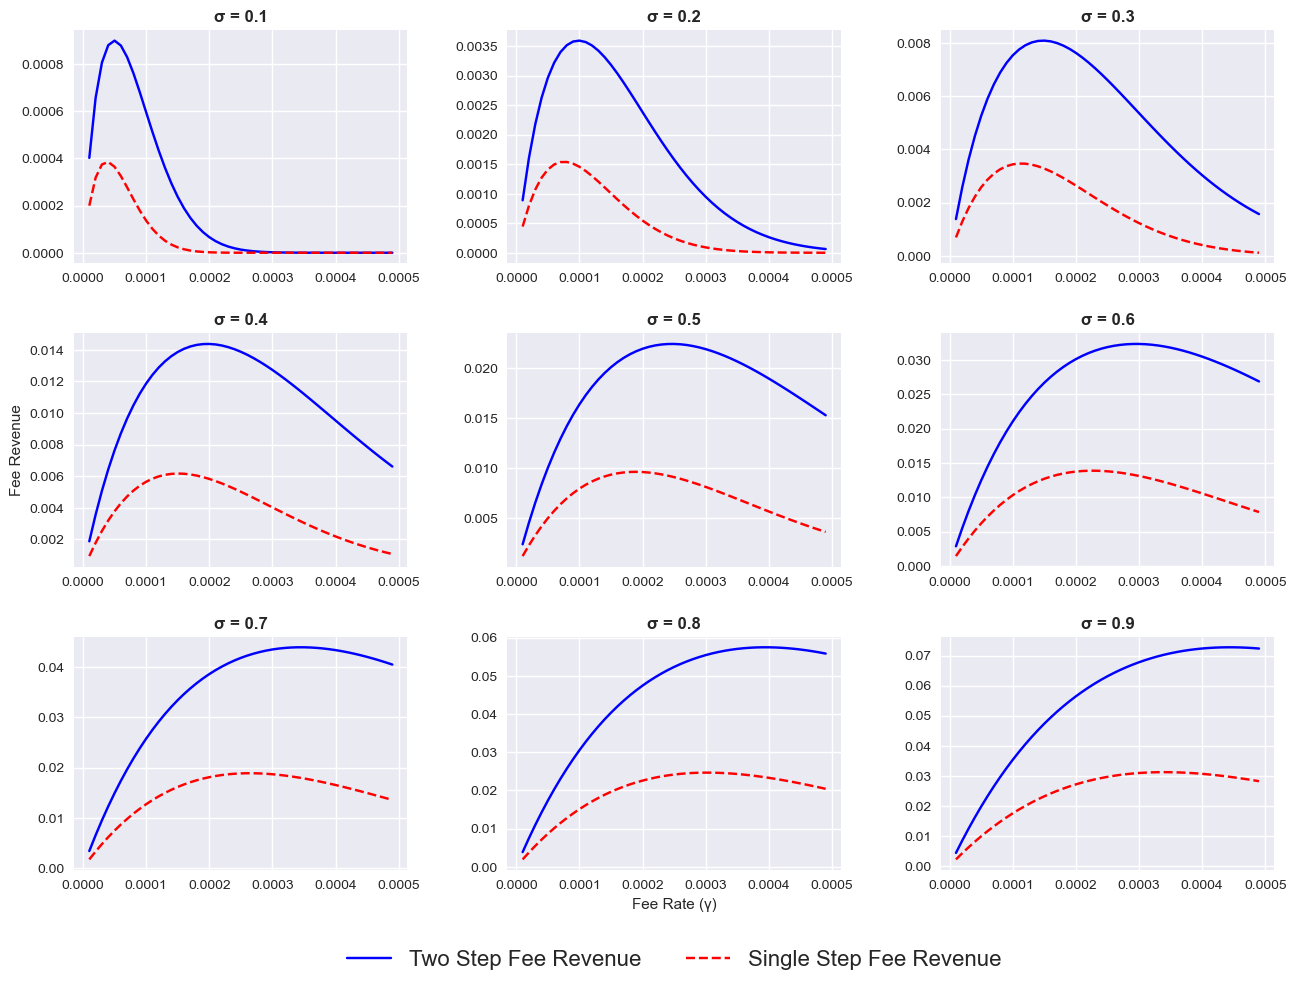

In [57]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def plot_metrics(df, metric_names):
    # Get unique sigma values
    unique_sigmas = sorted(df['sigma'].unique())
    
    # Create a 3x3 grid of subplots with extra space for legend
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()  # Flatten for easier indexing
    
    colors = ['b', 'r']
    linestyles = ['-', '--']
    
    # Store legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Create plots for each sigma value
    for idx, sigma in enumerate(unique_sigmas):
        if idx >= 9:  # Safety check for more than 9 sigma values
            break
            
        # Filter data for current sigma
        sigma_data = df[df['sigma'] == sigma]
        
        # Create plot for each metric
        ax = axes[idx]
        for i, metric_name in enumerate(metric_names):
            line = ax.plot(sigma_data['gamma'], sigma_data[metric_name], 
                         color=colors[i % len(colors)], 
                         linestyle=linestyles[i % len(linestyles)])
            
            # Collect legend info from first subplot only
            if idx == 0:
                legend_handles.extend(line)
                if metric_name == 'single_step_fee_revenue':
                    legend_labels.append('Single Step Fee Revenue')
                else:
                    legend_labels.append('Two Step Fee Revenue')
        
        # Customize plot
        ax.set_title(f'σ = {sigma:.1f}', fontsize=12, fontweight='bold')
        
        # Only add x-label to the bottom row (indices 6,7,8)
        if idx == 7:
            ax.set_xlabel('Fee Rate (γ)', fontsize=11)
        else:
            ax.set_xlabel('')
            
        # Only add y-label to the middle plot on the left side (index 3)
        if idx == 3:
            ax.set_ylabel('Fee Revenue', fontsize=11)
        else:
            ax.set_ylabel('')
            
        ax.grid(True)
    
    # Hide any unused subplots
    for idx in range(len(unique_sigmas), 9):
        axes[idx].set_visible(False)

    # Place legend at the bottom
    fig.legend(legend_handles, legend_labels, 
              loc='upper center', bbox_to_anchor=(0.5, 0.02),  # x=0.5 centers it horizontally, y=-0.1 puts it below plots
              fontsize=16, title_fontsize=16,
              ncol=2)  # ncol=2 makes the legend items appear in 2 columns horizontally

    # Adjust subplot spacing to make room at bottom
    plt.subplots_adjust(left=0.1, right=0.9, top=0.92, bottom=0.08,  # increase bottom margin (0.08 -> 0.2)
                       hspace=0.3, wspace=0.3)
    plt.show()

initial_pool_value = 2e6
df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/CPMM/TwoStep/results/two_step_result.csv")
df.loc[:,'single_step_fee_revenue'] = df.loc[:,'first_step_fee_revenue']
df.loc[:,'total_fee_revenue'] = df.loc[:,'single_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")


plot_metrics(df, ["total_fee_revenue", "single_step_fee_revenue"])

In [42]:
initial_pool_value = 2e6
df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/CPMM/TwoStep/results/two_step_result_theta.csv")
df.loc[:,'single_step_fee_revenue'] = df.loc[:,'first_step_fee_revenue']
df.loc[:,'total_fee_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")


There are 894 cases in which LP has profits in two steps
There are 892 cases in which LP has profits in one step


In [7]:
print(df.head().to_markdown())

|    |   sigma |   gamma |   theta |   first_step_fee_revenue |   first_step_pool_value |   second_step_fee_revenue |   second_step_pool_value |   single_step_fee_revenue |   total_fee_revenue |   first_step_lp_revenue |   lp_revenue |
|---:|--------:|--------:|--------:|-------------------------:|------------------------:|--------------------------:|-------------------------:|--------------------------:|--------------------:|------------------------:|-------------:|
|  0 |     0.1 |   1e-05 |    -1   |              0.000199317 |             2.00001e+06 |               0.00020223  |              2.00001e+06 |               0.000199317 |         0.000401547 |                8.24351  |      8.24371 |
|  1 |     0.1 |   1e-05 |    -0.5 |              0.000199316 |             2e+06       |               0.000202227 |              2e+06       |               0.000199316 |         0.000401543 |                3.93895  |      3.93916 |
|  2 |     0.1 |   1e-05 |     0   |              0.0001

In [16]:
initial_pool_value = 2e6
df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/CPMM/TwoStep/results/two_step_result.csv")
df.loc[:,'single_step_fee_revenue'] = df.loc[:,'first_step_fee_revenue']
df.loc[:,'total_fee_revenue'] = df.loc[:,'single_step_fee_revenue'] + df.loc[:,'second_step_fee_revenue']
df.loc[:,'first_step_lp_revenue'] = df.loc[:,'first_step_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
df.loc[:,'lp_revenue'] = df.loc[:,'total_fee_revenue'] + df.loc[:,'second_step_pool_value'] - initial_pool_value
# check if there is any positive lp_revenue
print(f"There are {len(df[df['lp_revenue'] > 1e-8])} cases in which LP has profits in two steps")
print(f"There are {len(df[df['first_step_lp_revenue'] > 1e-8])} cases in which LP has profits in one step")



There are 13 cases in which LP has profits in two steps
There are 10 cases in which LP has profits in one step


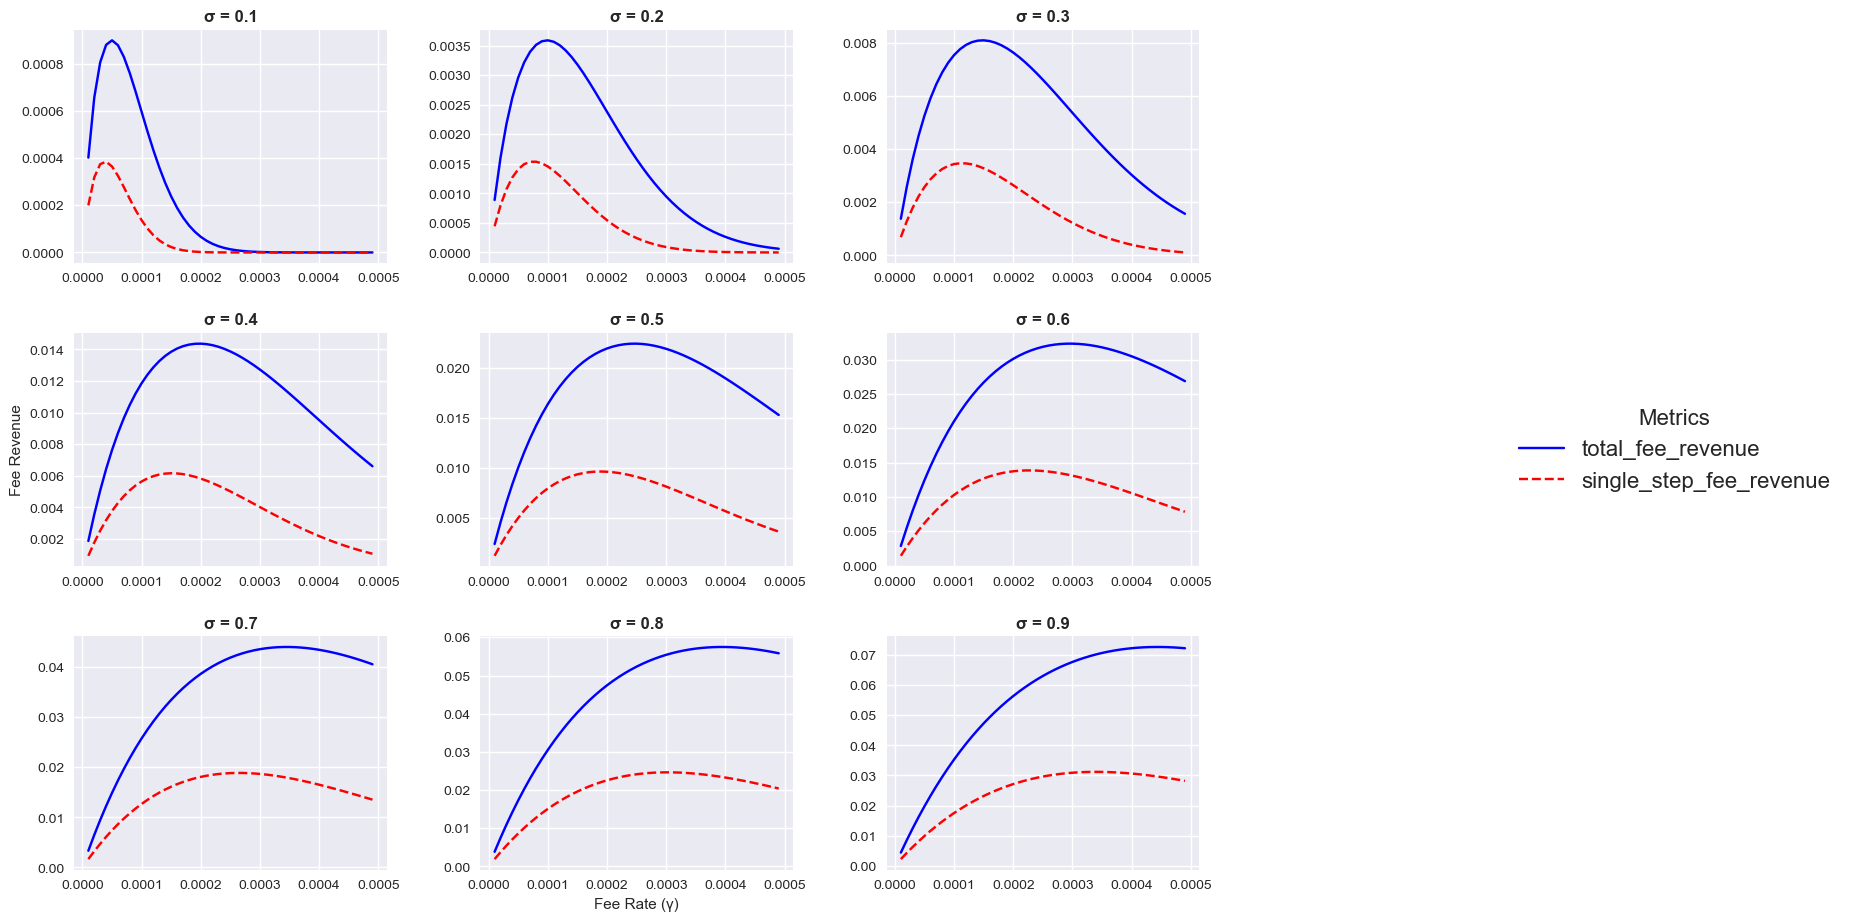

In [41]:
plot_metrics(df, ["total_fee_revenue", "single_step_fee_revenue"])

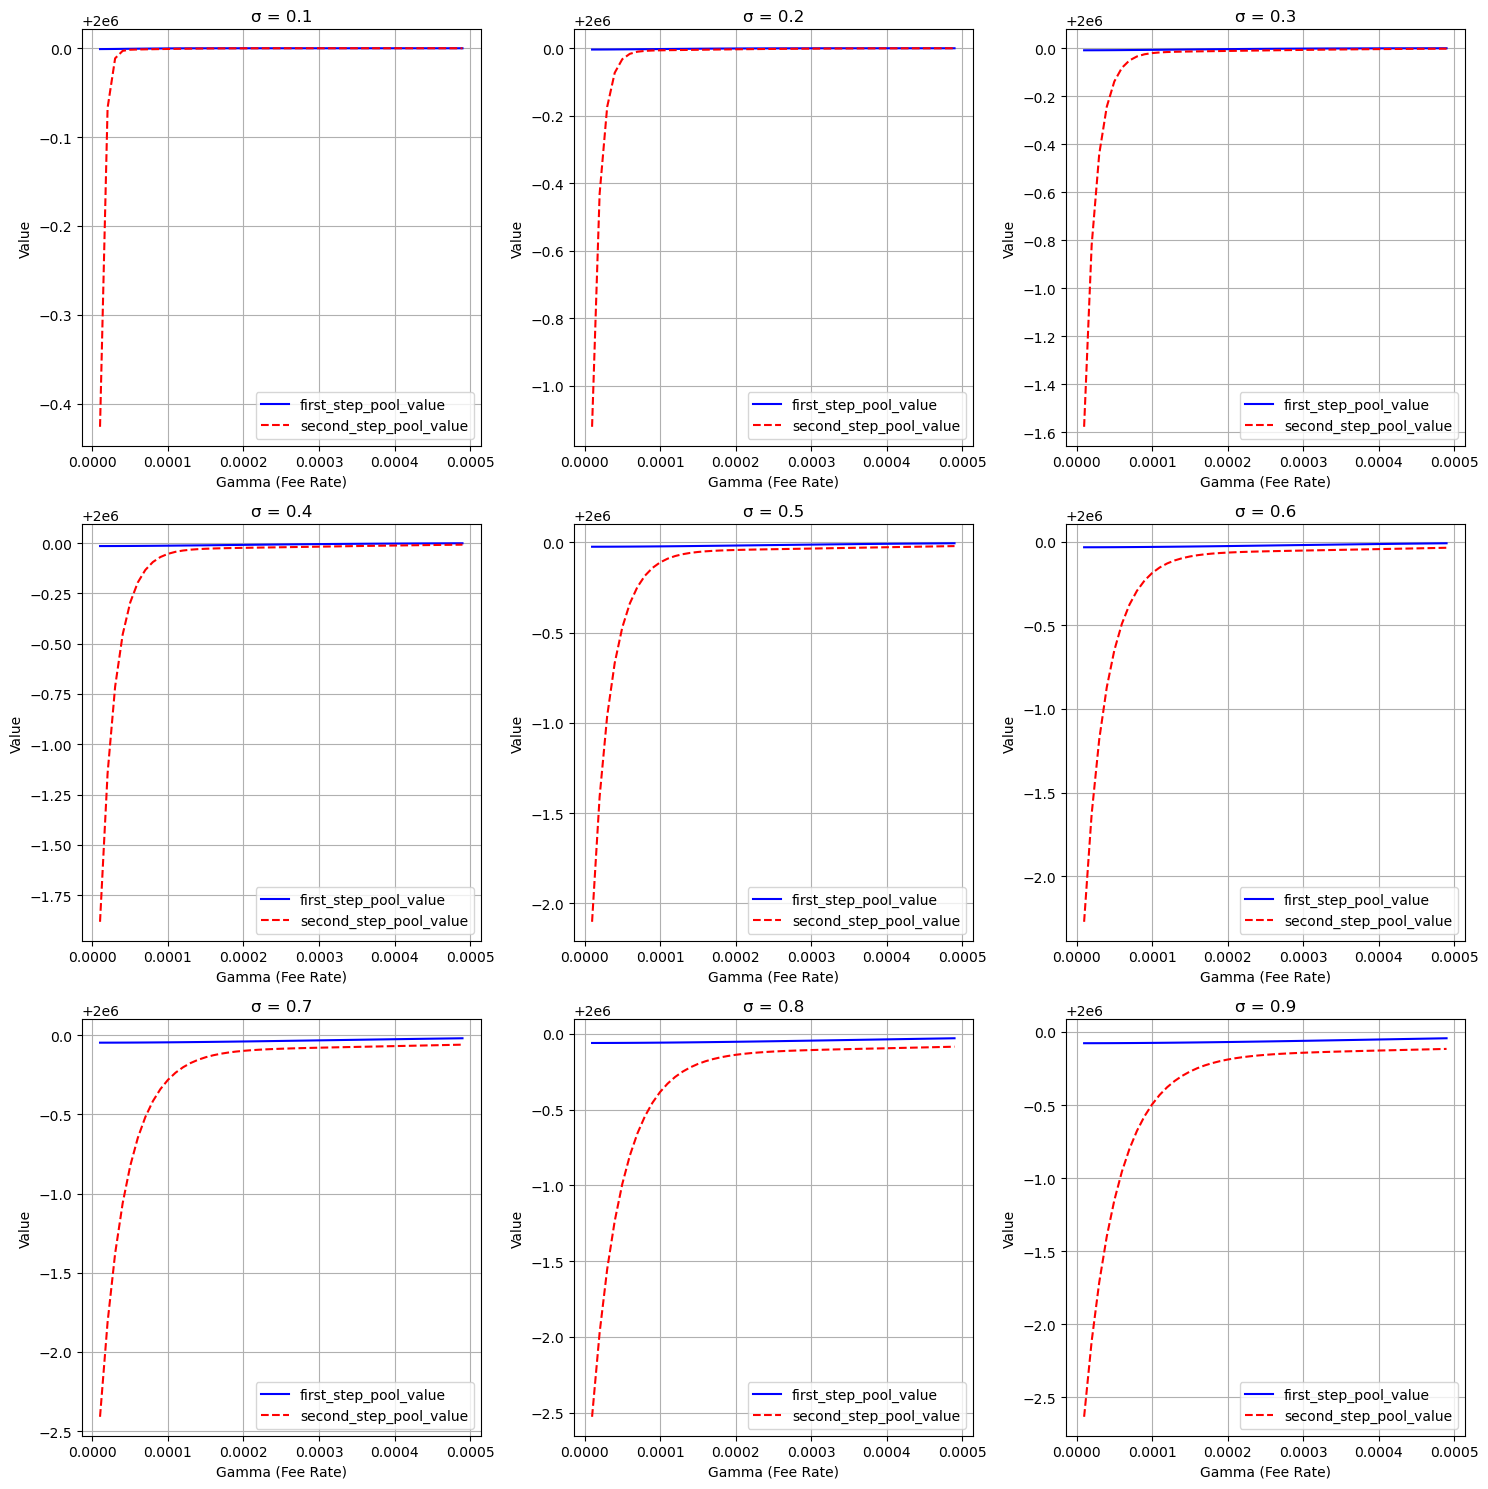

In [4]:
plot_metrics(df, ["first_step_pool_value", "second_step_pool_value"])

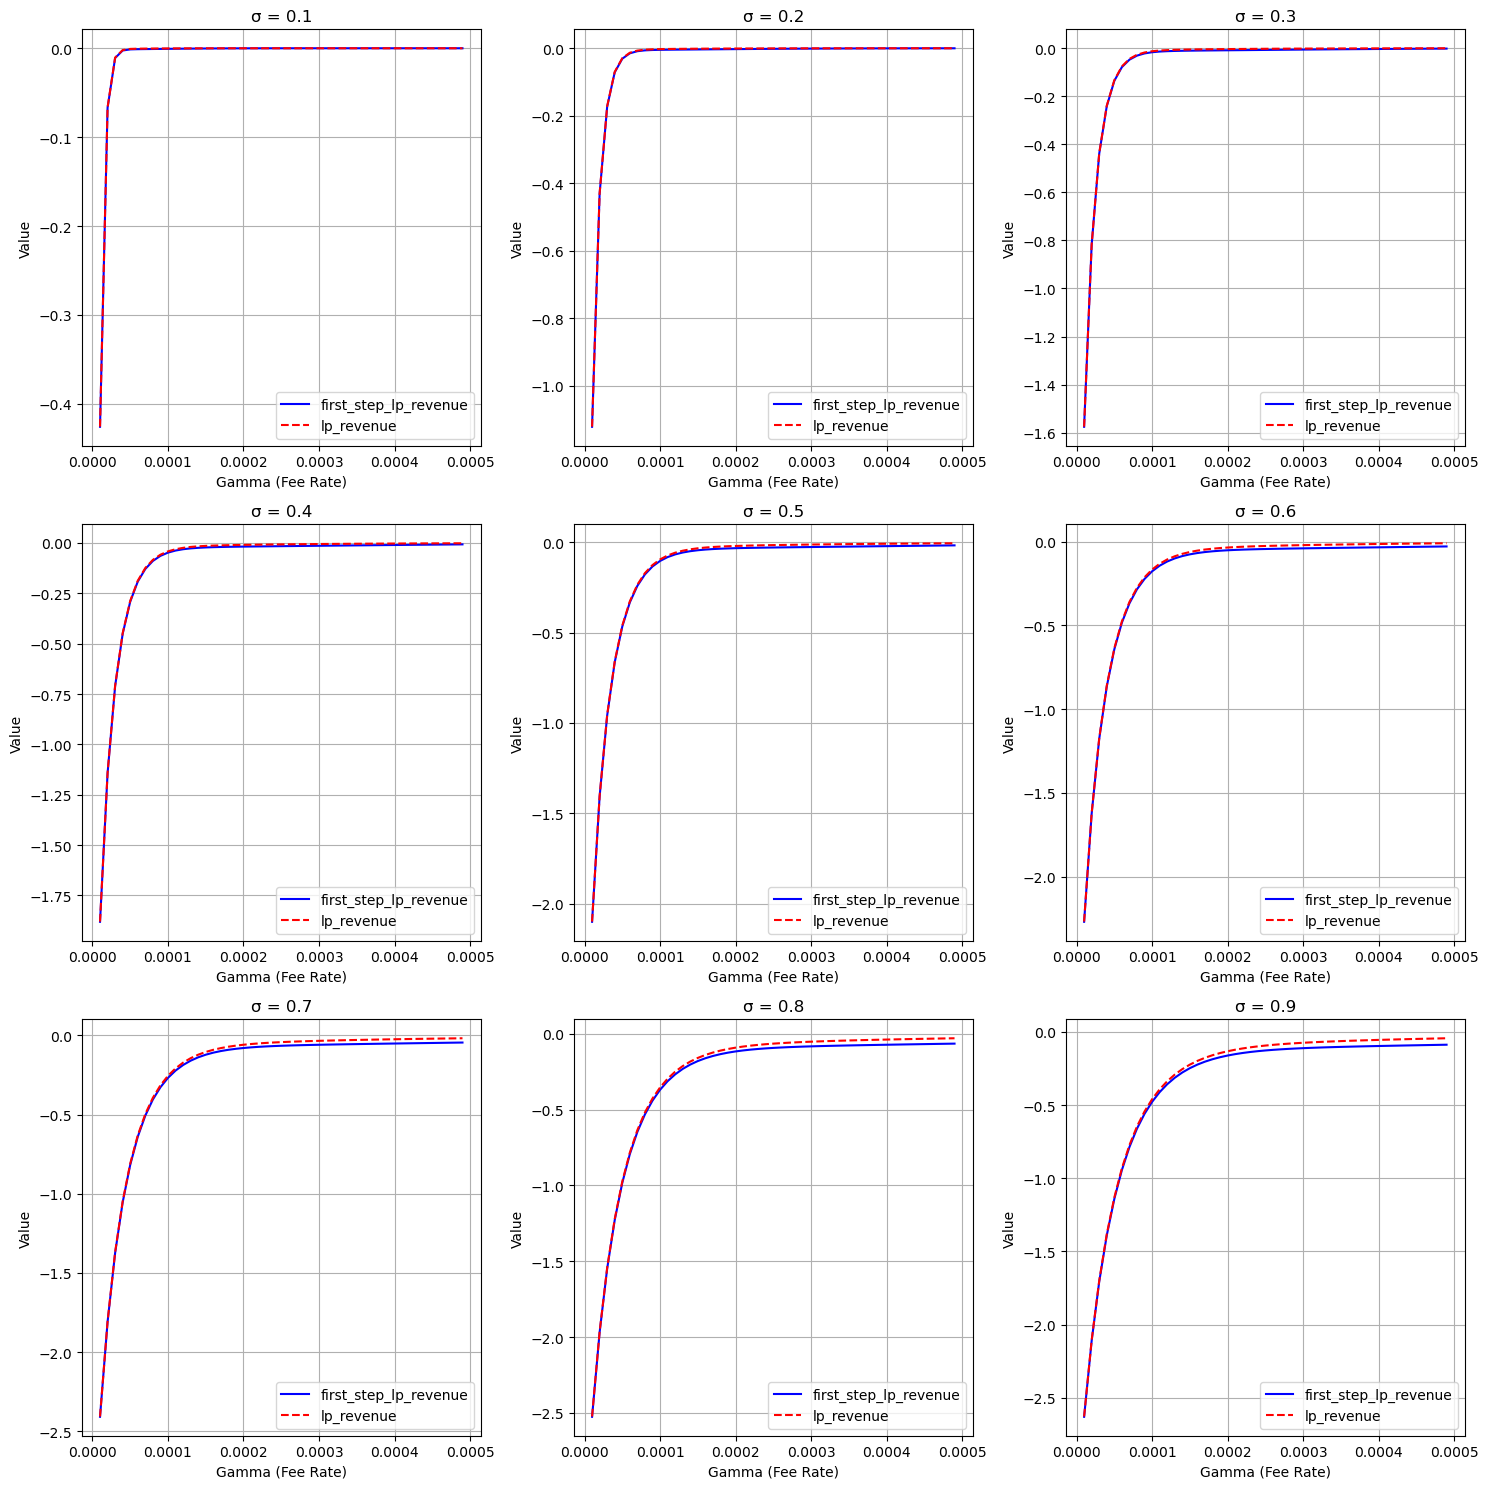

In [5]:
plot_metrics(df, ["first_step_lp_revenue", "lp_revenue"])